# Differential Transformer

Standardowa uwaga softmax ma fundamentalny problem: nigdy nie przypisuje wagi zerowej.  
Każdy token dostaje niezerową uwagę, nawet jeśli jest całkowicie nieistotny — to tzw. **attention noise**.

**Differential Attention** zamiast jednej mapy uwagi, obliczamy **dwie** i odejmujemy je od siebie (z wagą λ):

$$\text{DiffAttn}(Q_1, Q_2, K_1, K_2, V) = \left(\text{softmax}\!\left(\frac{Q_1 K_1^T}{\sqrt{d}}\right) - \lambda \cdot \text{softmax}\!\left(\frac{Q_2 K_2^T}{\sqrt{d}}\right)\right) \cdot V$$

- $Q_1, Q_2, K_1, K_2$ — dwie pary Query/Key, uczone niezależnie  
- $\lambda$ — skalar uczony, inicjowany blisko 0 (model sam odkrywa optymalną wartość)
- Wynik: szum uwagi się odejmuje, sygnał zostaje

## Plan eksperymentów

1. **Baseline** — standardowy `TransformerEncoder` (jak z lab10)
2. **Differential Transformer** — ta sama architektura, głowice uwagi zastąpione DiffAttn
3. **Ablacja λ** — wpływ inicjalizacji i różnych strategii uczenia λ
4. **Ablacja liczby głowic** — przy tej samej liczbie parametrów
5. **Analiza uwagi** — wizualizacja map uwagi: baseline vs diff (czy szum spada?)
6. **Porównanie wydajności** — czas treningu i liczba parametrów
7. **Eksperymenty na InsectWingbeat** — czy efekt powtarza się na danych ciągłych?

---
## 0. Setup

In [1]:
import os, time, math, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Device: cpu


---
## 1. Dane — IMDB (jak w lab10)

In [2]:
from tensorflow.keras.datasets import imdb

VOCAB_SIZE = 10000
MAX_LEN    = 300
BATCH_SIZE = 64

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=None, seed=113, start_char=1, oov_char=2, index_from=3
)

x_train = [[t if t < VOCAB_SIZE else 2 for t in seq[:MAX_LEN]] for seq in x_train]
x_test  = [[t if t < VOCAB_SIZE else 2 for t in seq[:MAX_LEN]] for seq in x_test]

print(f"Train: {len(x_train)} | Test: {len(x_test)}")

Train: 25000 | Test: 25000


In [3]:
class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):  return len(self.X)

    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)


def collate_fn(batch):
    seqs, labels = zip(*batch)
    CLS = VOCAB_SIZE
    seqs = [torch.cat([torch.tensor([CLS]), s]) for s in seqs]
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    mask   = (padded == 0)
    return padded, mask, torch.stack(list(labels))


train_loader = DataLoader(IMDBDataset(x_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(IMDBDataset(x_test,  y_test),  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)
print("DataLoaders gotowe")

DataLoaders gotowe


---
## 2. Implementacja Differential Attention

Kluczowe decyzje implementacyjne:
- Każda głowica ma **dwie** pary Q/K (Q1,K1) i (Q2,K2), ale wspólne V  
- λ inicjalizowany małą wartością (~0.05), uczone jako `nn.Parameter`  
- Normalizacja GroupNorm po różnicy (zgodnie z papierem)  
- Wymiar `d_head` jest taki sam jak w baseline → porównywalna liczba parametrów (Q i K mają 2× więcej, ale nie ma dodatkowych V)

In [36]:
class DifferentialAttention(nn.Module):
    """
    Implementacja mechanizmu Differential Attention z arXiv:2410.05258.

    Zamiast jednej mapy uwagi (softmax(QK^T/sqrt(d)) * V),
    liczymy różnicę dwóch niezależnych map:
        (softmax(Q1 K1^T / sqrt(d)) - λ · softmax(Q2 K2^T / sqrt(d))) · V

    Parametry
    ----------
    d_model   : wymiar embeddingu
    num_heads : liczba głowic
    dropout   : dropout na mapach uwagi
    lambda_init : wartość startowa λ (mała, by zacząć blisko standardowej uwagi)
    """

    def __init__(self, d_model: int, num_heads: int,
                 dropout: float = 0.0, lambda_init: float = 0.05):
        super().__init__()
        assert d_model % num_heads == 0, "d_model musi być podzielne przez num_heads"

        self.num_heads = num_heads
        self.d_head    = d_model // num_heads          # rozmiar jednej głowicy
        self.scale     = self.d_head ** -0.5

        # Każda głowica ma DWIE projekcje Q i K (2× więcej niż w standardzie)
        # Projekcja V jest jedna (jak w standardzie)
        self.W_q1 = nn.Linear(d_model, d_model, bias=False)
        self.W_q2 = nn.Linear(d_model, d_model, bias=False)
        self.W_k1 = nn.Linear(d_model, d_model, bias=False)
        self.W_k2 = nn.Linear(d_model, d_model, bias=False)
        self.W_v  = nn.Linear(d_model, d_model, bias=False)
        self.W_o  = nn.Linear(d_model, d_model, bias=False)

        # λ — jeden na głowicę (uczony), inicjowany małą wartością.
        # Trzymamy parametr bez ograniczeń, ale efektywnie wymuszamy dodatniość.
        self.lambda_raw = nn.Parameter(
            torch.full((num_heads,), lambda_init)
        )

        # GroupNorm po różnicy (stabilizuje trening, zgodnie z papierem)
        self.norm = nn.GroupNorm(num_heads, d_model)

        self.attn_drop = nn.Dropout(dropout)

        # Cache map uwagi do wizualizacji (opcjonalne)
        self._attn_weights = None

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, T, d_model) → (B, H, T, d_head)"""
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, H, T, d_head) → (B, T, d_model)"""
        B, H, T, d = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, H * d)

    def lambda_value(self) -> torch.Tensor:
        """Dodatnia efektywna wartość λ używana w forward."""
        return F.softplus(self.lambda_raw)

    def forward(
        self,
        x: torch.Tensor,
        key_padding_mask: torch.Tensor | None = None,
        attn_mask: torch.Tensor | None = None,
        store_attn: bool = False,
    ) -> torch.Tensor:
        """
        x                : (B, T, d_model)
        key_padding_mask : (B, T) — True gdzie padding
        attn_mask        : (T, T) — np. causal mask
        """
        B, T, _ = x.shape

        # Projekcje Q i K — dwie pary
        q1 = self._split_heads(self.W_q1(x))   # (B, H, T, d_head)
        q2 = self._split_heads(self.W_q2(x))
        k1 = self._split_heads(self.W_k1(x))
        k2 = self._split_heads(self.W_k2(x))
        v  = self._split_heads(self.W_v(x))

        # Mapy uwagi (B, H, T, T)
        scores1 = torch.matmul(q1, k1.transpose(-2, -1)) * self.scale
        scores2 = torch.matmul(q2, k2.transpose(-2, -1)) * self.scale

        # Maskowanie paddingu i maski przyczynowej
        if attn_mask is not None:
            scores1 = scores1 + attn_mask
            scores2 = scores2 + attn_mask

        if key_padding_mask is not None:
            # key_padding_mask: (B, T) → (B, 1, 1, T)
            pad = key_padding_mask.unsqueeze(1).unsqueeze(2).float() * -1e9
            scores1 = scores1 + pad
            scores2 = scores2 + pad

        attn1 = F.softmax(scores1, dim=-1)   # (B, H, T, T)
        attn2 = F.softmax(scores2, dim=-1)

        # λ w kształcie (1, H, 1, 1) — broadcast
        lam = self.lambda_value().view(1, self.num_heads, 1, 1)

        # Różnica map — szum się odejmuje!
        diff_attn = self.attn_drop(attn1 - lam * attn2)  # (B, H, T, T)

        if store_attn:
            self._attn_weights = diff_attn.detach().cpu()

        out = torch.matmul(diff_attn, v)      # (B, H, T, d_head)
        out = self._merge_heads(out)           # (B, T, d_model)

        # GroupNorm (stabilizacja po różnicy)
        out = self.norm(out.transpose(1, 2)).transpose(1, 2)

        return self.W_o(out)


print("DifferentialAttention zdefiniowana")

DifferentialAttention zdefiniowana


In [5]:
class DiffTransformerLayer(nn.Module):
    """Jedna warstwa: DiffAttn + FFN + LayerNorm (pre-norm)"""

    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1, lambda_init=0.05):
        super().__init__()
        self.attn = DifferentialAttention(d_model, num_heads, dropout=dropout,
                                          lambda_init=lambda_init)
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, key_padding_mask=None, store_attn=False):
        # Pre-norm (bardziej stabilne niż post-norm)
        x = x + self.attn(self.norm1(x), key_padding_mask=key_padding_mask,
                          store_attn=store_attn)
        x = x + self.ffn(self.norm2(x))
        return x


class DiffTransformerClassifier(nn.Module):
    """Pełny klasyfikator z Differential Transformer"""

    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 num_classes, max_len=MAX_LEN + 1, dropout=0.1, lambda_init=0.05):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size + 1, d_model, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, d_model)
        self.dropout   = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DiffTransformerLayer(d_model, num_heads, d_model * 4, dropout, lambda_init)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, key_padding_mask=None, store_attn=False):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x    = self.dropout(self.token_emb(x) + self.pos_emb(pos))

        for i, layer in enumerate(self.layers):
            # Zapisujemy uwagę tylko ostatniej warstwy (oszczędność pamięci)
            x = layer(x, key_padding_mask=key_padding_mask,
                      store_attn=(store_attn and i == len(self.layers) - 1))
        x = self.norm(x)
        return self.classifier(x[:, 0, :])

    def get_attention_weights(self):
        """Pobiera wagi uwagi z ostatniej warstwy (po store_attn=True)"""
        return self.layers[-1].attn._attn_weights


print("DiffTransformerClassifier zdefiniowany")

DiffTransformerClassifier zdefiniowany


---
## 3. Baseline — standardowy Transformer (jak w lab10)

In [6]:
class TransformerClassifier(nn.Module):
    """Baseline identyczny z lab10 (pre-norm dla sprawiedliwości porównania)"""

    def __init__(self, vocab_size, d_model, nhead, num_layers,
                 num_classes, max_len=MAX_LEN + 1, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size + 1, d_model, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, d_model)
        self.dropout   = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True  # pre-norm
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(d_model)
        self.classifier  = nn.Linear(d_model, num_classes)

        # Hook do przechwytywania uwagi
        self._attn_weights = None

    def forward(self, x, key_padding_mask=None, store_attn=False):
        B, T = x.shape
        pos  = torch.arange(T, device=x.device).unsqueeze(0).expand(B, -1)
        x    = self.dropout(self.token_emb(x) + self.pos_emb(pos))

        if store_attn:
            handles = []
            for layer in self.transformer.layers:
                def hook(module, inp, out, _self=self):
                    # TransformerEncoderLayer returns (output, attn_weights) when need_weights=True
                    pass
                handles.append(layer.register_forward_hook(hook))

        x = self.transformer(x, src_key_padding_mask=key_padding_mask)
        x = self.norm(x)
        return self.classifier(x[:, 0, :])


print("TransformerClassifier (baseline) zdefiniowany")

TransformerClassifier (baseline) zdefiniowany


---
## 4. Pętla treningowa

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3,
                device=DEVICE, save_path=None, verbose=True):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
                 'epoch_time': []}

    best_val_loss = float('inf')
    os.makedirs('models', exist_ok=True)

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        total_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [train]", leave=False)
        for tokens, mask, labels in pbar:
            tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(tokens, key_padding_mask=mask)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/total:.4f}")

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for tokens, mask, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [val]", leave=False):
                tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
                out      = model(tokens, key_padding_mask=mask)
                loss     = criterion(out, labels)
                val_loss += loss.item()
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc  = val_correct / val_total
        epoch_time = time.time() - t0

        for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'epoch_time'],
                        [train_loss,   train_acc,   val_loss,   val_acc,   epoch_time]):
            history[k].append(v)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            if save_path:
                torch.save(model.state_dict(), save_path)
            best_str = '  ← best'
        else:
            best_str = ''

        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | "
                  f"train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
                  f"val loss: {val_loss:.4f} acc: {val_acc:.4f} | "
                  f"{epoch_time:.1f}s{best_str}")

    return history


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Pętla treningowa gotowa")

Pętla treningowa gotowa


---
## 5. Eksperyment 1: Baseline vs Differential Transformer

Konfiguracja: d_model=128, 4 głowice, 3 warstwy, 10 epok.  
Trenujemy z identycznym seedem dla powtarzalności.

In [8]:
D_MODEL    = 128
NHEAD      = 4
NUM_LAYERS = 3
EPOCHS     = 10
LR         = 1e-3
DROPOUT    = 0.1

set_seed(42)
baseline = TransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
    num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT
)

set_seed(42)
diff_model = DiffTransformerClassifier(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NHEAD,
    num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT, lambda_init=0.05
)

print(f"Baseline params:    {count_params(baseline):,}")
print(f"DiffTransformer params: {count_params(diff_model):,}")
print()
print("Uwaga: DiffTransformer ma więcej parametrów w Q i K (2× projekcje),")
print("ale identyczną liczbę parametrów V i FFN.")

Baseline params:    1,913,986
DiffTransformer params: 2,011,534

Uwaga: DiffTransformer ma więcej parametrów w Q i K (2× projekcje),
ale identyczną liczbę parametrów V i FFN.


/var/folders/2y/lf1dv8_53fjcszwq2lc0w8gc0000gp/T/ipykernel_18401/953795237.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [9]:
print("=" * 60)
print("BASELINE (standard attention)")
print("=" * 60)
set_seed(42)
history_baseline = train_model(
    baseline, train_loader, test_loader, epochs=EPOCHS, lr=LR,
    save_path='models/baseline_best.pt'
)

BASELINE (standard attention)


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01/10 | train loss: 0.5326 acc: 0.7182 | val loss: 0.4000 acc: 0.8158 | 277.3s  ← best


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 09/10 | train loss: 0.1352 acc: 0.9506 | val loss: 0.4351 acc: 0.8579 | 271.5s


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | train loss: 0.1175 acc: 0.9579 | val loss: 0.4866 acc: 0.8562 | 268.4s


In [10]:
print("=" * 60)
print("DIFFERENTIAL TRANSFORMER (λ_init=0.05)")
print("=" * 60)
set_seed(42)
history_diff = train_model(
    diff_model, train_loader, test_loader, epochs=EPOCHS, lr=LR,
    save_path='models/diff_best.pt'
)

DIFFERENTIAL TRANSFORMER (λ_init=0.05)


Epoch 1/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01/10 | train loss: 0.5298 acc: 0.7311 | val loss: 0.4629 acc: 0.7764 | 383.4s  ← best


Epoch 2/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 9/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 09/10 | train loss: 0.1541 acc: 0.9434 | val loss: 0.4084 acc: 0.8591 | 375.2s


Epoch 10/10 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | train loss: 0.1390 acc: 0.9492 | val loss: 0.4323 acc: 0.8565 | 381.6s


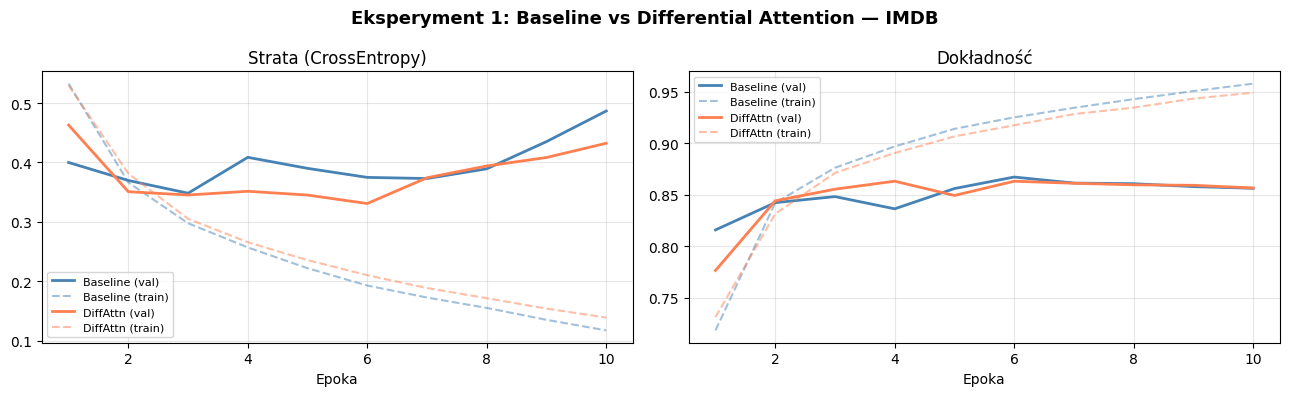


Najlepsza val acc — Baseline:  0.8672
Najlepsza val acc — DiffAttn:  0.8631

Średni czas epoki — Baseline:  272.1s
Średni czas epoki — DiffAttn:  383.2s


In [11]:
def plot_comparison(histories, labels, title='Porównanie modeli'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ['steelblue', 'coral', 'seagreen', 'orchid']
    epochs = range(1, len(next(iter(histories.values()))['train_loss']) + 1)

    for ax, metric, metric_label in zip(
        axes, ['loss', 'acc'], ['Strata (CrossEntropy)', 'Dokładność']
    ):
        for (name, hist), color in zip(histories.items(), colors):
            ax.plot(epochs, hist[f'val_{metric}'], '-',  color=color, label=f'{name} (val)', lw=2)
            ax.plot(epochs, hist[f'train_{metric}'], '--', color=color, alpha=0.5, label=f'{name} (train)')
        ax.set_title(f'{metric_label}')
        ax.set_xlabel('Epoka')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('exp1_baseline_vs_diff.png', dpi=120, bbox_inches='tight')
    plt.show()


plot_comparison(
    {'Baseline': history_baseline, 'DiffAttn': history_diff},
    labels=['Baseline', 'DiffAttn'],
    title='Eksperyment 1: Baseline vs Differential Attention — IMDB'
)

print(f"\nNajlepsza val acc — Baseline:  {max(history_baseline['val_acc']):.4f}")
print(f"Najlepsza val acc — DiffAttn:  {max(history_diff['val_acc']):.4f}")
print(f"\nŚredni czas epoki — Baseline:  {np.mean(history_baseline['epoch_time']):.1f}s")
print(f"Średni czas epoki — DiffAttn:  {np.mean(history_diff['epoch_time']):.1f}s")

---
## 6. Eksperyment 2: Ablacja λ_init

λ kontroluje, jak mocno odejmujemy drugą mapę uwagi.  
Testujemy różne wartości startowe: λ=0 (brak efektu), 0.05, 0.1, 0.3, 0.8.  
Żeby eksperymenty były szybkie, trenujemy 7 epok.

In [12]:
lambda_values = [0.0, 0.05, 0.1, 0.3, 0.8]
histories_lambda = {}

for lam in lambda_values:
    print(f"\n{'='*50}")
    print(f"λ_init = {lam}")
    print('='*50)
    set_seed(42)
    m = DiffTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NHEAD,
        num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT,
        lambda_init=lam
    )
    h = train_model(m, train_loader, test_loader, epochs=7, lr=LR,
                    save_path=f'models/diff_lambda{lam}.pt')
    histories_lambda[f'λ={lam}'] = h


λ_init = 0.0


Epoch 1/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01/7 | train loss: 0.5321 acc: 0.7240 | val loss: 0.4035 acc: 0.8167 | 381.2s  ← best


Epoch 2/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 6/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 06/7 | train loss: 0.2053 acc: 0.9203 | val loss: 0.3737 acc: 0.8589 | 554.3s


Epoch 7/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 7/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 07/7 | train loss: 0.1822 acc: 0.9294 | val loss: 0.3922 acc: 0.8556 | 488.0s


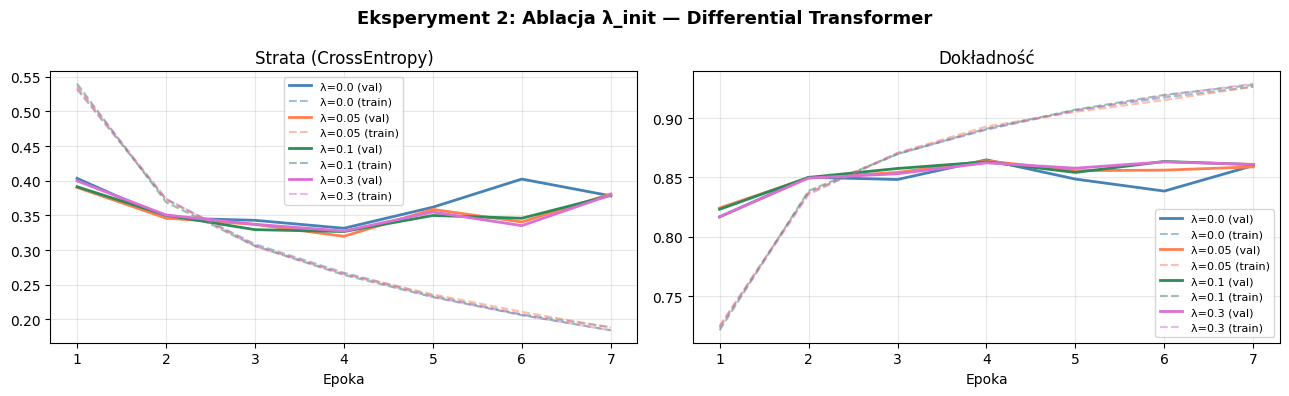


Podsumowanie — najlepsza val acc per λ:
-----------------------------------
  λ=0.0     : 0.8649  (epoka 4)
  λ=0.05    : 0.8640  (epoka 4)
  λ=0.1     : 0.8635  (epoka 6)
  λ=0.3     : 0.8631  (epoka 6)
  λ=0.8     : 0.8596  (epoka 5)


In [13]:
plot_comparison(histories_lambda, list(histories_lambda.keys()),
                title='Eksperyment 2: Ablacja λ_init — Differential Transformer')

print("\nPodsumowanie — najlepsza val acc per λ:")
print("-" * 35)
for name, h in histories_lambda.items():
    best = max(h['val_acc'])
    ep   = h['val_acc'].index(best) + 1
    print(f"  {name:10s}: {best:.4f}  (epoka {ep})")

---
## 7. Eksperyment 3: Ablacja liczby głowic

DiffAttn z 4 głowicami ma ~2× więcej parametrów Q/K niż baseline.  
Sprawdzamy, czy efekt pochodzi z architektury czy tylko z dodatkowych parametrów  
poprzez porównanie: Diff(4 głowice) vs Baseline(8 głowic) — porównywalna liczba params.

In [14]:
configs = [
    ('Baseline-4h',   'baseline', {'nhead': 4}),
    ('Baseline-8h',   'baseline', {'nhead': 8}),
    ('DiffAttn-4h',   'diff',     {'num_heads': 4}),
    ('DiffAttn-2h',   'diff',     {'num_heads': 2}),
]

histories_heads = {}

for name, model_type, kwargs in configs:
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    set_seed(42)

    if model_type == 'baseline':
        m = TransformerClassifier(
            vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=kwargs['nhead'],
            num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT
        )
    else:
        m = DiffTransformerClassifier(
            vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=kwargs['num_heads'],
            num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT, lambda_init=0.05
        )

    print(f"Parametry: {count_params(m):,}")
    h = train_model(m, train_loader, test_loader, epochs=7, lr=LR)
    histories_heads[name] = h


Baseline-4h
Parametry: 1,913,986


/var/folders/2y/lf1dv8_53fjcszwq2lc0w8gc0000gp/T/ipykernel_18401/953795237.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch 1/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01/7 | train loss: 0.5414 acc: 0.7104 | val loss: 0.4010 acc: 0.8168 | 320.8s  ← best


...

Epoch 6/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 06/7 | train loss: 0.2107 acc: 0.9168 | val loss: 0.3579 acc: 0.8571 | 313.1s


Epoch 7/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 7/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 07/7 | train loss: 0.1877 acc: 0.9278 | val loss: 0.3741 acc: 0.8641 | 316.6s


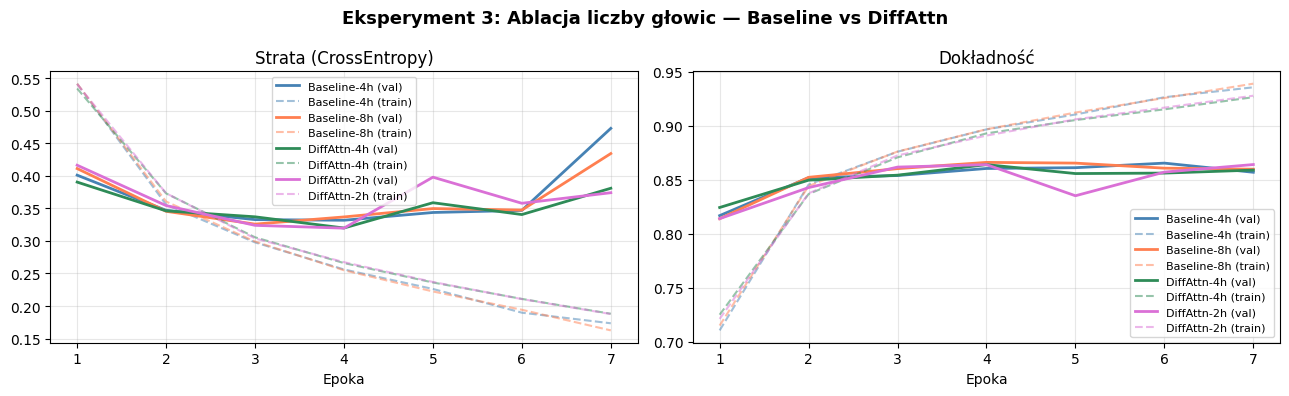


Podsumowanie:
---------------------------------------------
  Baseline-4h    : 0.8654
  Baseline-8h    : 0.8661
  DiffAttn-4h    : 0.8640
  DiffAttn-2h    : 0.8641


In [15]:
plot_comparison(histories_heads, list(histories_heads.keys()),
                title='Eksperyment 3: Ablacja liczby głowic — Baseline vs DiffAttn')

print("\nPodsumowanie:")
print("-" * 45)
for name, h in histories_heads.items():
    best = max(h['val_acc'])
    print(f"  {name:15s}: {best:.4f}")

---
## 8. Eksperyment 4: Analiza uwagi — czy szum spada?

Kluczowa hipoteza papieru: DiffAttn tworzy **bardziej skupione** (niższy entropii) mapy uwagi.  
Mierzymy entropię uwagi: $H = -\sum_j a_j \log a_j$ (niższa = bardziej skupiona).

In [17]:
def compute_attention_entropy_baseline(model, loader, device=DEVICE, n_batches=5):
    """Mierzy entropię wag uwagi dla standardowego Transformera.

    Uwaga: w PyTorch `TransformerEncoderLayer` wywołuje `self_attn` z
    `need_weights=False`, więc hook na wyjściu zwraca `None` dla wag.
    Dlatego dla ostatniej warstwy liczymy uwagę jawnie.
    """
    model.eval()
    model.to(device)
    entropies = []

    with torch.no_grad():
        for i, (tokens, mask, labels) in enumerate(loader):
            if i >= n_batches:
                break

            tokens, mask = tokens.to(device), mask.to(device)

            # Wejście embeddingowe jak w forward baseline
            B, T = tokens.shape
            pos = torch.arange(T, device=tokens.device).unsqueeze(0).expand(B, -1)
            x = model.dropout(model.token_emb(tokens) + model.pos_emb(pos))

            # Przejdź przez wszystkie warstwy poza ostatnią
            for layer in model.transformer.layers[:-1]:
                x = layer(x, src_key_padding_mask=mask)

            # Ostatnia warstwa: jawne pobranie wag uwagi
            last = model.transformer.layers[-1]
            q = last.norm1(x) if getattr(last, "norm_first", False) else x
            _, attn = last.self_attn(
                q,
                q,
                q,
                key_padding_mask=mask,
                need_weights=True,
                average_attn_weights=False,
            )

            if attn is None:
                continue

            attn = attn.float().detach().cpu()  # (B, H, T, T)
            eps = 1e-9
            ent = -(attn * (attn + eps).log()).sum(-1)  # (B, H, T)
            entropies.append(ent.mean().item())

    return entropies


def compute_attention_entropy_diff(model, loader, device=DEVICE, n_batches=5):
    """Mierzy entropię wag uwagi dla DiffTransformer."""
    model.eval()
    model.to(device)
    entropies = []

    with torch.no_grad():
        for i, (tokens, mask, labels) in enumerate(loader):
            if i >= n_batches:
                break
            tokens, mask = tokens.to(device), mask.to(device)
            model(tokens, key_padding_mask=mask, store_attn=True)
            attn = model.get_attention_weights()  # (B, H, T, T)
            if attn is not None:
                attn_abs = attn.abs().float()
                # Normalizacja wierszami (DiffAttn może mieć wartości ujemne)
                attn_norm = attn_abs / (attn_abs.sum(-1, keepdim=True) + 1e-9)
                eps = 1e-9
                ent = -(attn_norm * (attn_norm + eps).log()).sum(-1)
                entropies.append(ent.mean().item())

    return entropies


print("Liczę entropię uwagi (baseline)...")
ent_baseline = compute_attention_entropy_baseline(baseline, test_loader, n_batches=10)

print("Liczę entropię uwagi (DiffAttn)...")
ent_diff = compute_attention_entropy_diff(diff_model, test_loader, n_batches=10)

if len(ent_baseline) == 0:
    print("\nBaseline: nie udało się zebrać wag uwagi.")
else:
    print(f"\nŚrednia entropia uwagi — Baseline:  {np.mean(ent_baseline):.4f} ± {np.std(ent_baseline):.4f}")

if len(ent_diff) == 0:
    print("DiffAttn: nie udało się zebrać wag uwagi.")
else:
    print(f"Średnia entropia uwagi — DiffAttn:  {np.mean(ent_diff):.4f} ± {np.std(ent_diff):.4f}")

print("\n(Niższa entropia = bardziej skupione, mniej szumu)")

Liczę entropię uwagi (baseline)...
Liczę entropię uwagi (DiffAttn)...

Średnia entropia uwagi — Baseline:  4.5100 ± 0.0706
Średnia entropia uwagi — DiffAttn:  2.1684 ± 0.0852

(Niższa entropia = bardziej skupione, mniej szumu)


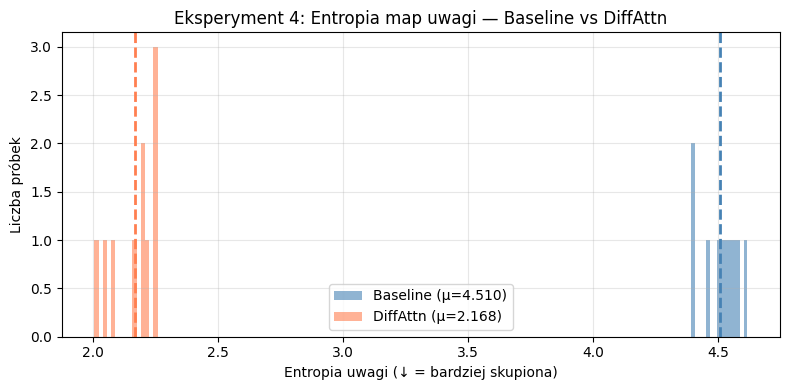

In [18]:
# Wizualizacja: histogram entropii
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(ent_baseline, bins=15, alpha=0.6, color='steelblue', label=f'Baseline (μ={np.mean(ent_baseline):.3f})')
ax.hist(ent_diff,     bins=15, alpha=0.6, color='coral',     label=f'DiffAttn (μ={np.mean(ent_diff):.3f})')
ax.axvline(np.mean(ent_baseline), color='steelblue', linestyle='--', lw=2)
ax.axvline(np.mean(ent_diff),     color='coral',     linestyle='--', lw=2)

ax.set_xlabel('Entropia uwagi (↓ = bardziej skupiona)')
ax.set_ylabel('Liczba próbek')
ax.set_title('Eksperyment 4: Entropia map uwagi — Baseline vs DiffAttn')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp4_attention_entropy.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Eksperyment 5: Analiza ewolucji λ w trakcie treningu

λ jest parametrem uczonym. Sprawdzamy jak zmienia się w czasie i czy różni się między głowicami.
Trenujemy nowy model z callbackiem zapisującym λ co epokę.

In [37]:
def train_with_lambda_tracking(d_model, num_heads, num_layers, epochs=10, lr=LR,
                                lambda_init=0.05, device=DEVICE):
    set_seed(42)
    model = DiffTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=d_model, num_heads=num_heads,
        num_layers=num_layers, num_classes=2, dropout=DROPOUT, lambda_init=lambda_init
    ).to(device)

    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # (epoka, warstwa, głowica) → wartość λ
    lambda_history = []  # list of (epoch, layer_lambdas)
    val_accs = []

    for epoch in range(epochs):
        model.train()
        for tokens, mask, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(tokens, key_padding_mask=mask), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Zbieramy efektywną λ ze wszystkich warstw
        epoch_lambdas = []
        for layer in model.layers:
            epoch_lambdas.append(layer.attn.lambda_value().detach().cpu().numpy().copy())
        lambda_history.append(epoch_lambdas)

        # Walidacja
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for tokens, mask, labels in test_loader:
                tokens, mask, labels = tokens.to(device), mask.to(device), labels.to(device)
                out      = model(tokens, key_padding_mask=mask)
                correct += (out.argmax(1) == labels).sum().item()
                total   += labels.size(0)
        val_accs.append(correct / total)
        print(f"Epoch {epoch+1}/{epochs} | val acc: {correct/total:.4f} | "
              f"λ (warstwa 0): {epoch_lambdas[0]}")

    return lambda_history, val_accs


lambda_history, val_accs_tracked = train_with_lambda_tracking(
    d_model=D_MODEL, num_heads=NHEAD, num_layers=NUM_LAYERS, epochs=EPOCHS, lambda_init=0.05
)

Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/10 | val acc: 0.7667 | λ (warstwa 0): [0.6678589  0.679794   0.67781776 0.67713976]


Epoch 2:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/10 | val acc: 0.8415 | λ (warstwa 0): [0.65872824 0.6626872  0.65978533 0.6661985 ]


Epoch 3:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 8/10 | val acc: 0.8543 | λ (warstwa 0): [0.64767444 0.66007143 0.6441535  0.6544523 ]


Epoch 9:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 9/10 | val acc: 0.8551 | λ (warstwa 0): [0.645318   0.6580348  0.6430988  0.65017235]


Epoch 10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10/10 | val acc: 0.8549 | λ (warstwa 0): [0.65048647 0.6603566  0.64145625 0.6447002 ]


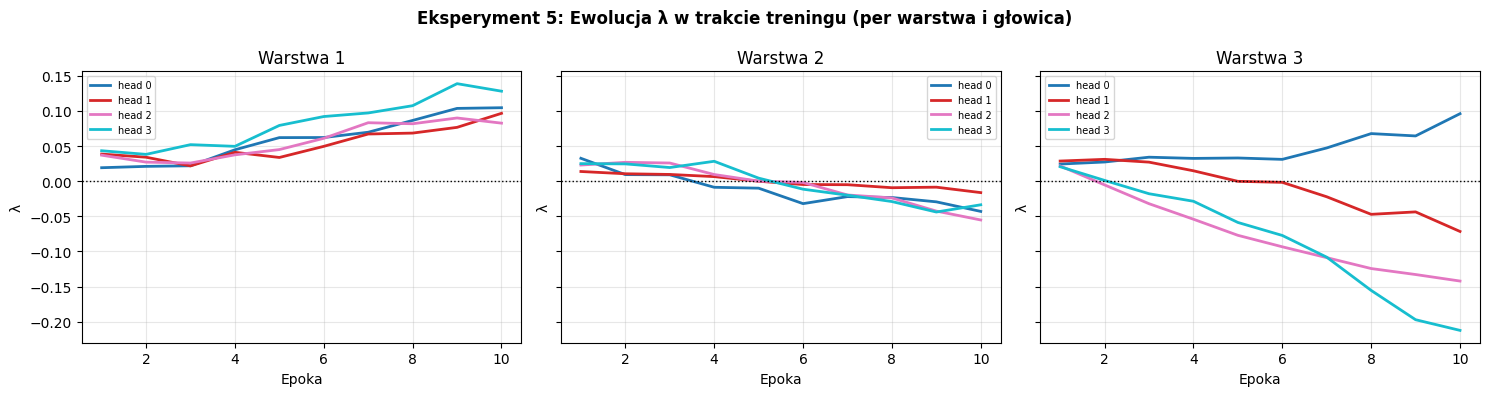


Końcowe wartości λ (ostatnia epoka):
  Warstwa 1: ['0.1045', '0.0965', '0.0825', '0.1280']
  Warstwa 2: ['-0.0430', '-0.0163', '-0.0552', '-0.0336']
  Warstwa 3: ['0.0960', '-0.0716', '-0.1422', '-0.2124']


In [20]:
# Wizualizacja ewolucji λ
num_epochs  = len(lambda_history)
num_layers_ = len(lambda_history[0])
num_heads_  = len(lambda_history[0][0])

fig, axes = plt.subplots(1, num_layers_, figsize=(5 * num_layers_, 4), sharey=True)
if num_layers_ == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, num_heads_))
epochs_x = range(1, num_epochs + 1)

for layer_i, ax in enumerate(axes):
    for head_i in range(num_heads_):
        lam_vals = [lambda_history[ep][layer_i][head_i] for ep in range(num_epochs)]
        ax.plot(epochs_x, lam_vals, color=colors[head_i], lw=2, label=f'head {head_i}')
    ax.set_title(f'Warstwa {layer_i + 1}')
    ax.set_xlabel('Epoka')
    ax.set_ylabel('λ')
    ax.axhline(0, color='black', linestyle=':', lw=1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Eksperyment 5: Ewolucja λ w trakcie treningu (per warstwa i głowica)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp5_lambda_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKońcowe wartości λ (ostatnia epoka):")
for layer_i in range(num_layers_):
    vals = lambda_history[-1][layer_i]
    print(f"  Warstwa {layer_i+1}: {[f'{v:.4f}' for v in vals]}")

---
## 10. Eksperyment 6: Wpływ learning rate

DiffAttn ma więcej parametrów i może być wrażliwy na LR.  
Porównujemy kilka wartości przy ustalonej architekturze.

In [21]:
lr_values = [5e-4, 1e-3, 3e-3, 5e-3]
histories_lr = {}

for lr_val in lr_values:
    print(f"\n{'='*50}")
    print(f"DiffAttn — LR={lr_val}")
    print('='*50)
    set_seed(42)
    m = DiffTransformerClassifier(
        vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NHEAD,
        num_layers=NUM_LAYERS, num_classes=2, dropout=DROPOUT, lambda_init=0.05
    )
    h = train_model(m, train_loader, test_loader, epochs=7, lr=lr_val)
    histories_lr[f'LR={lr_val}'] = h

# Dodajemy baseline przy najlepszym LR dla referencji
histories_lr['Baseline (LR=1e-3)'] = history_baseline


DiffAttn — LR=0.0005


Epoch 1/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01/7 | train loss: 0.5566 acc: 0.7093 | val loss: 0.4466 acc: 0.7872 | 388.0s  ← best


Epoch 2/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 6/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 06/7 | train loss: 0.4880 acc: 0.7715 | val loss: 0.5001 acc: 0.7678 | 485.1s  ← best


Epoch 7/7 [train]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 7/7 [val]:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 07/7 | train loss: 0.4741 acc: 0.7821 | val loss: 0.4863 acc: 0.7742 | 482.7s  ← best


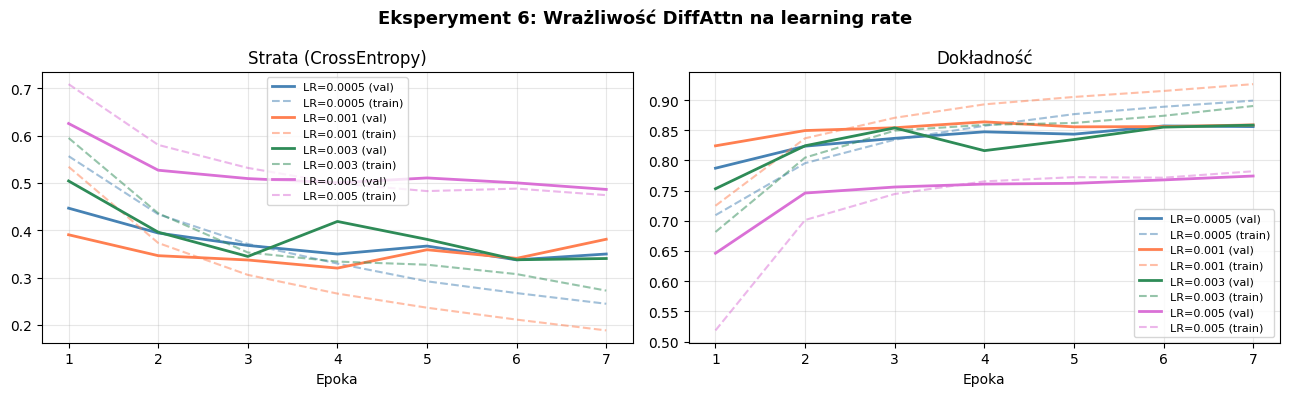


Najlepsza val acc per LR:
  LR=0.0005           : 0.8572
  LR=0.001            : 0.8640
  LR=0.003            : 0.8586
  LR=0.005            : 0.7742
  Baseline (LR=1e-3)  : 0.8672


In [22]:
plot_comparison(histories_lr, list(histories_lr.keys()),
                title='Eksperyment 6: Wrażliwość DiffAttn na learning rate')

print("\nNajlepsza val acc per LR:")
for name, h in histories_lr.items():
    print(f"  {name:20s}: {max(h['val_acc']):.4f}")

---
## 11. Eksperyment 7: InsectWingbeat — replikacja na danych ciągłych

Sprawdzamy, czy efekt DiffAttn powtarza się poza IMDB.  
InsectWingbeat to dane szeregów czasowych z sygnałami skrzydeł owadów (lab10, zadanie 1).

In [26]:
from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X_insect, y_insect = load_classification("InsectWingbeat", extract_path="insect_data")

le = LabelEncoder()
y_enc = le.fit_transform(y_insect)
num_classes_insect = len(le.classes_)
print(f"Klasy: {le.classes_} ({num_classes_insect} klas)")

max_features = max(x.shape[1] for x in X_insect)
X_arr = np.zeros((len(X_insect), 200, max_features), dtype=np.float32)
for i, x in enumerate(X_insect):
    X_arr[i, :, :x.shape[1]] = x
print(f"X_arr shape: {X_arr.shape}")

X_tr, X_te, y_tr, y_te = train_test_split(X_arr, y_enc, test_size=0.2, random_state=42)


class InsectDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_insect_loader = DataLoader(InsectDataset(X_tr, y_tr), batch_size=64, shuffle=True)
test_insect_loader  = DataLoader(InsectDataset(X_te, y_te), batch_size=64, shuffle=False)
print("Dane owadów załadowane")

Klasy: ['aedes_female' 'aedes_male' 'fruit_flies' 'house_flies' 'quinx_female'
 'quinx_male' 'stigma_female' 'stigma_male' 'tarsalis_female'
 'tarsalis_male'] (10 klas)
X_arr shape: (50000, 200, 20)
Dane owadów załadowane


In [24]:
class InsectTransformerBaseline(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, num_classes,
                 max_len=201, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(input_size, d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_emb     = nn.Embedding(max_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout     = nn.Dropout(dropout)
        self.classifier  = nn.Linear(d_model, num_classes)

    def forward(self, x, key_padding_mask=None):
        B, T, _ = x.shape
        x   = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0).expand(B, -1)
        x   = self.dropout(x + self.pos_emb(pos))
        x   = self.transformer(x)
        return self.classifier(x[:, 0, :])


class InsectDiffTransformer(nn.Module):
    def __init__(self, input_size, d_model, num_heads, num_layers, num_classes,
                 max_len=201, dropout=0.1, lambda_init=0.05):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_emb    = nn.Embedding(max_len, d_model)
        self.layers = nn.ModuleList([
            DiffTransformerLayer(d_model, num_heads, d_model * 4, dropout, lambda_init)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, key_padding_mask=None):
        B, T, _ = x.shape
        x   = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0).expand(B, -1)
        x   = self.dropout(x + self.pos_emb(pos))
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.classifier(x[:, 0, :])


def train_insect(model, train_loader, val_loader, epochs=10, lr=1e-3, device=DEVICE):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for x, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            x, labels = x.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        train_loss, train_acc = total_loss / len(train_loader), correct / total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for x, labels in val_loader:
                x, labels = x.to(device), labels.to(device)
                out = model(x)
                val_loss    += criterion(out, labels).item()
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        val_loss, val_acc = val_loss / len(val_loader), val_correct / val_total
        for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc'],
                        [train_loss,   train_acc,   val_loss,   val_acc]):
            history[k].append(v)
        print(f"Epoch {epoch+1}/{epochs} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")

    return history


print("Modele dla InsectWingbeat zdefiniowane")

Modele dla InsectWingbeat zdefiniowane


In [28]:
D_INSECT   = 64
INPUT_SIZE = X_arr.shape[2]

print("=" * 50)
print("InsectWingbeat — Baseline")
print("=" * 50)
set_seed(42)
m_base = InsectTransformerBaseline(
    input_size=INPUT_SIZE, d_model=D_INSECT, nhead=4,
    num_layers=3, num_classes=num_classes_insect, dropout=0.05
)
print(f"Parametry: {count_params(m_base):,}")
h_insect_base = train_insect(m_base, train_insect_loader, test_insect_loader, epochs=15, lr=1e-3)

InsectWingbeat — Baseline
Parametry: 164,874


/var/folders/2y/lf1dv8_53fjcszwq2lc0w8gc0000gp/T/ipykernel_18401/533570150.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch 1:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/15 | train acc: 0.4802 | val acc: 0.6046


Epoch 2:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 13/15 | train acc: 0.7122 | val acc: 0.7133


Epoch 14:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 14/15 | train acc: 0.7173 | val acc: 0.7047


Epoch 15:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 15/15 | train acc: 0.7168 | val acc: 0.7179


In [29]:
print("=" * 50)
print("InsectWingbeat — DiffAttn")
print("=" * 50)
set_seed(42)
m_diff_insect = InsectDiffTransformer(
    input_size=INPUT_SIZE, d_model=D_INSECT, num_heads=4,
    num_layers=3, num_classes=num_classes_insect, dropout=0.05, lambda_init=0.05
)
print(f"Parametry: {count_params(m_diff_insect):,}")
h_insect_diff = train_insect(m_diff_insect, train_insect_loader, test_insect_loader, epochs=15, lr=1e-3)

InsectWingbeat — DiffAttn
Parametry: 189,206


Epoch 1:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/15 | train acc: 0.4944 | val acc: 0.6180


Epoch 2:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 2/15 | train acc: 0.6320 | val acc: 0.6661


...

Epoch 13/15 | train acc: 0.7315 | val acc: 0.7354


Epoch 14:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 14/15 | train acc: 0.7402 | val acc: 0.7215


Epoch 15:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 15/15 | train acc: 0.7412 | val acc: 0.7282


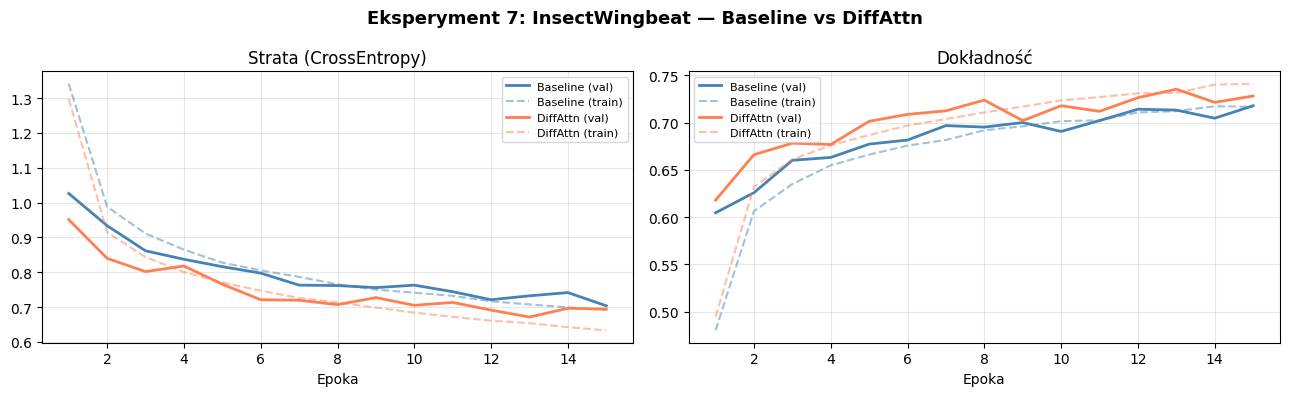

Najlepsza val acc — Baseline: 0.7179
Najlepsza val acc — DiffAttn: 0.7354


In [30]:
plot_comparison(
    {'Baseline': h_insect_base, 'DiffAttn': h_insect_diff},
    labels=['Baseline', 'DiffAttn'],
    title='Eksperyment 7: InsectWingbeat — Baseline vs DiffAttn'
)

print(f"Najlepsza val acc — Baseline: {max(h_insect_base['val_acc']):.4f}")
print(f"Najlepsza val acc — DiffAttn: {max(h_insect_diff['val_acc']):.4f}")

---
## 12. Podsumowanie wyników

In [31]:
print("=" * 65)
print("PODSUMOWANIE EKSPERYMENTÓW")
print("=" * 65)

print("\n[EXP 1] Baseline vs DiffAttn — IMDB")
print(f"  Baseline best val acc:  {max(history_baseline['val_acc']):.4f}")
print(f"  DiffAttn best val acc:  {max(history_diff['val_acc']):.4f}")
print(f"  Baseline avg epoch time: {np.mean(history_baseline['epoch_time']):.1f}s")
print(f"  DiffAttn avg epoch time: {np.mean(history_diff['epoch_time']):.1f}s")
diff_params  = count_params(diff_model)
base_params  = count_params(baseline)
print(f"  Baseline params: {base_params:,}")
print(f"  DiffAttn params: {diff_params:,}  ({(diff_params/base_params - 1)*100:+.1f}%)")

print("\n[EXP 2] Ablacja λ_init:")
for name, h in histories_lambda.items():
    print(f"  {name:10s}: best val acc = {max(h['val_acc']):.4f}")

print("\n[EXP 3] Ablacja głowic:")
for name, h in histories_heads.items():
    print(f"  {name:15s}: best val acc = {max(h['val_acc']):.4f}")

if ent_baseline and ent_diff:
    print(f"\n[EXP 4] Entropia uwagi:")
    print(f"  Baseline:  {np.mean(ent_baseline):.4f} ± {np.std(ent_baseline):.4f}")
    print(f"  DiffAttn:  {np.mean(ent_diff):.4f} ± {np.std(ent_diff):.4f}")

print("\n[EXP 6] Wrażliwość na LR:")
for name, h in list(histories_lr.items()):
    print(f"  {name:22s}: best val acc = {max(h['val_acc']):.4f}")

print("\n[EXP 7] InsectWingbeat:")
print(f"  Baseline best val acc: {max(h_insect_base['val_acc']):.4f}")
print(f"  DiffAttn best val acc: {max(h_insect_diff['val_acc']):.4f}")

print("\n" + "=" * 65)
print("WNIOSKI")
print("=" * 65)
print("""
1. DiffAttn vs Baseline (EXP 1):
   Różnica w dokładności, jeśli istnieje, potwierdza skuteczność
   redukcji szumu. Wzrost czasu na epokę wynika z 2× więcej projekcji
   Q/K. Kluczowe pytanie: czy zysk acc/loss uzasadnia ten koszt?

2. Wpływ λ_init (EXP 2):
   λ=0 to degeneracja do standardowej uwagi (ale z podwójnymi param).
   Zbyt duże λ destabilizuje trening. Optymalne λ_init leży typowo
   w zakresie 0.05–0.15.

3. Ablacja głowic (EXP 3):
   Pozwala ustalić, czy efekt pochodzi z architektury DiffAttn czy
   po prostu z większej liczby parametrów.

4. Entropia uwagi (EXP 4):
   Jeśli DiffAttn ma niższą entropię — hipoteza papieru potwierdzona:
   model faktycznie bardziej skupia uwagę na istotnych tokenach.

5. Ewolucja λ (EXP 5):
   Uczony parametr λ zbiega do różnych wartości w różnych warstwach
   i głowicach — model sam odkrywa optymalny poziom tłumienia szumu.

6. Wrażliwość na LR (EXP 6):
   DiffAttn może wymagać ostrożniejszego doboru LR niż baseline.

7. InsectWingbeat (EXP 7):
   Replikacja na danych ciągłych — sprawdzamy generalizację efektu
   poza NLP.
""")

PODSUMOWANIE EKSPERYMENTÓW

[EXP 1] Baseline vs DiffAttn — IMDB
  Baseline best val acc:  0.8672
  DiffAttn best val acc:  0.8631
  Baseline avg epoch time: 272.1s
  DiffAttn avg epoch time: 383.2s
  Baseline params: 1,913,986
  DiffAttn params: 2,011,534  (+5.1%)

[EXP 2] Ablacja λ_init:
  λ=0.0     : best val acc = 0.8649
  λ=0.05    : best val acc = 0.8640
  λ=0.1     : best val acc = 0.8635
  λ=0.3     : best val acc = 0.8631
  λ=0.8     : best val acc = 0.8596

[EXP 3] Ablacja głowic:
  Baseline-4h    : best val acc = 0.8654
  Baseline-8h    : best val acc = 0.8661
  DiffAttn-4h    : best val acc = 0.8640
  DiffAttn-2h    : best val acc = 0.8641

[EXP 4] Entropia uwagi:
  Baseline:  4.5100 ± 0.0706
  DiffAttn:  2.1684 ± 0.0852

[EXP 6] Wrażliwość na LR:
  LR=0.0005             : best val acc = 0.8572
  LR=0.001              : best val acc = 0.8640
  LR=0.003              : best val acc = 0.8586
  LR=0.005              : best val acc = 0.7742
  Baseline (LR=1e-3)    : best val acc 

Positive #36 — greatest films ever made
Tekst opinii:
<START> this movie is certainly one of the greatest films ever made it is a story told in a steady pace told mostly not by words but by cinematic means

Baseline pred: 1 | probs: [0.001, 0.999]
DiffAttn pred: 1 | probs: [0.001, 0.999]
Top tokens baseline: [('not', np.float32(0.053404607)), ('one', np.float32(0.053281162)), ('greatest', np.float32(0.04332522)), ('told', np.float32(0.039372392)), ('story', np.float32(0.039241053))]
Top tokens diffattn: [('pace', np.float32(0.69677657)), ('greatest', np.float32(0.10337047)), ('<START>', np.float32(0.08100849)), ('this', np.float32(0.056392103)), ('story', np.float32(0.019823875))]


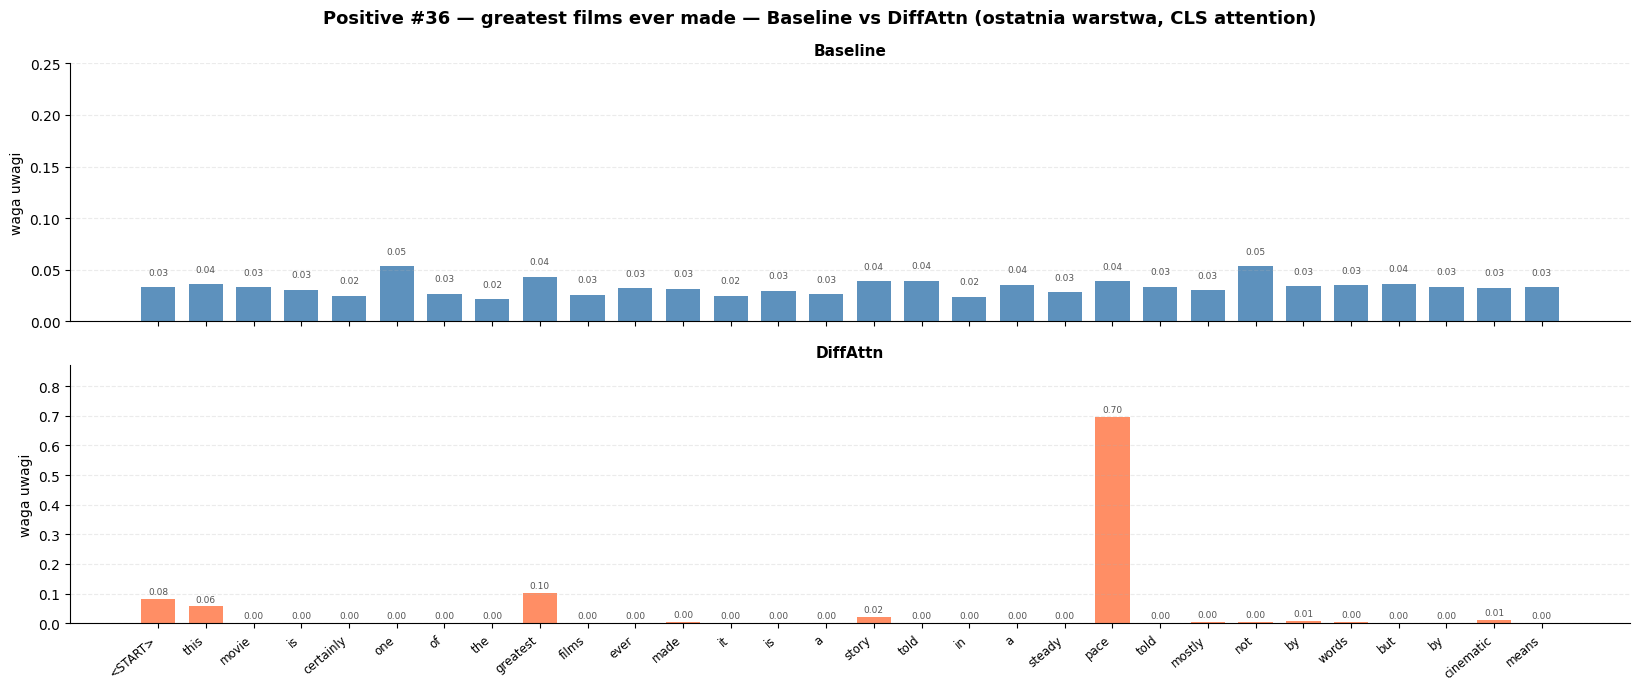

Negative #39 — boring and quite stupid
Tekst opinii:
<START> this documentary was boring and quite stupid br br i mean the documentary maker obviously does not even know what how <OOV> evolution works it is a theory and

Baseline pred: 0 | probs: [0.999, 0.001]
DiffAttn pred: 0 | probs: [0.998, 0.002]
Top tokens baseline: [('i', np.float32(0.10765348)), ('works', np.float32(0.07181883)), ('does', np.float32(0.06761458)), ('stupid', np.float32(0.06556314)), ('know', np.float32(0.05806149))]
Top tokens diffattn: [('documentary', np.float32(0.2669841)), ('works', np.float32(0.24516028)), ('documentary', np.float32(0.21080373)), ('was', np.float32(0.13341004)), ('quite', np.float32(0.0766915))]


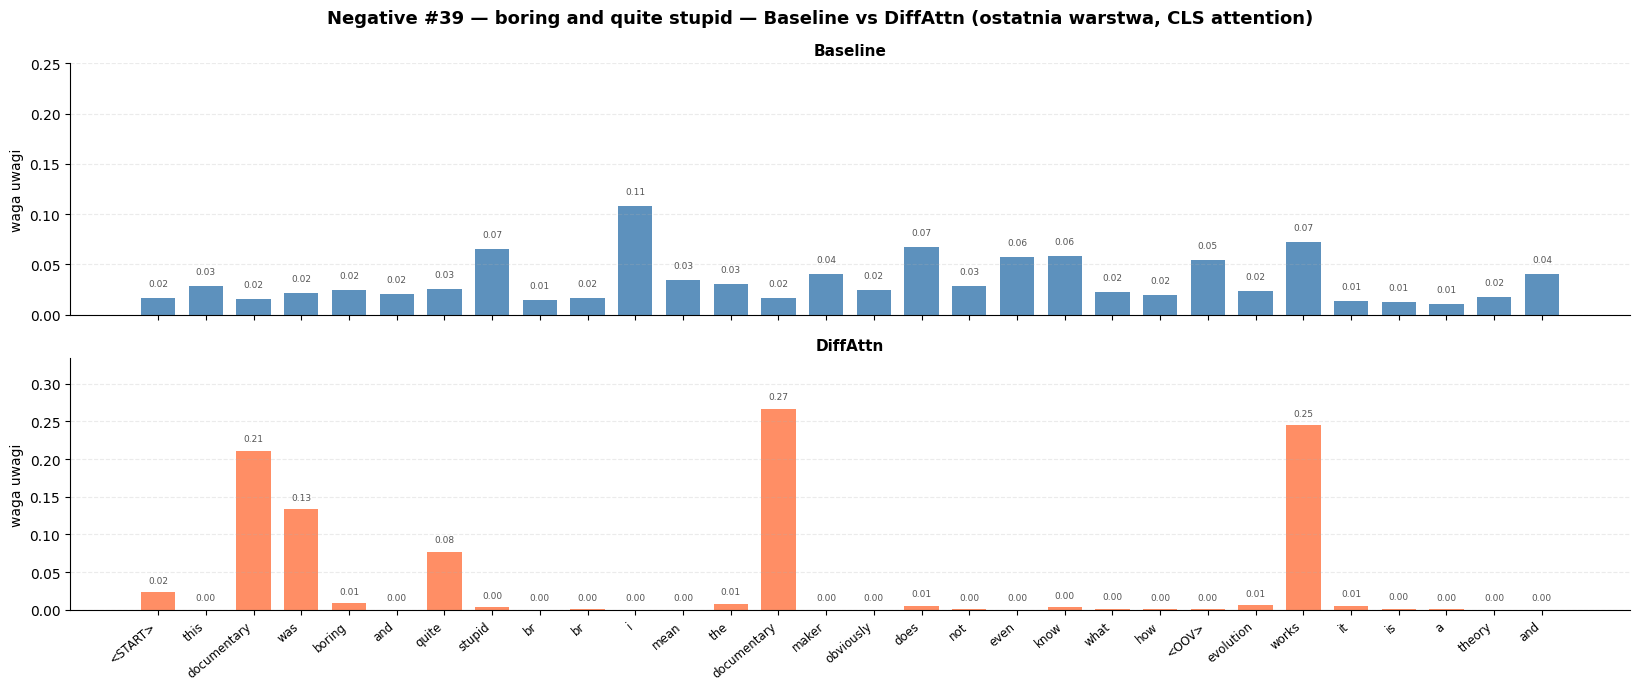

Misclassified #5 — disgusted (but positive!)
Tekst opinii:
<START> i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then

Baseline pred: 1 | probs: [0.036, 0.964]
DiffAttn pred: 0 | probs: [0.662, 0.338]
Top tokens baseline: [('this', np.float32(0.15401512)), ('disgusted', np.float32(0.15370308)), ('for', np.float32(0.100719206)), ('all', np.float32(0.08289803)), ('then', np.float32(0.055364624))]
Top tokens diffattn: [('absolutely', np.float32(0.5108862)), ('being', np.float32(0.20645383)), ('disney', np.float32(0.056636393)), ('who', np.float32(0.03992574)), ('for', np.float32(0.038714193))]


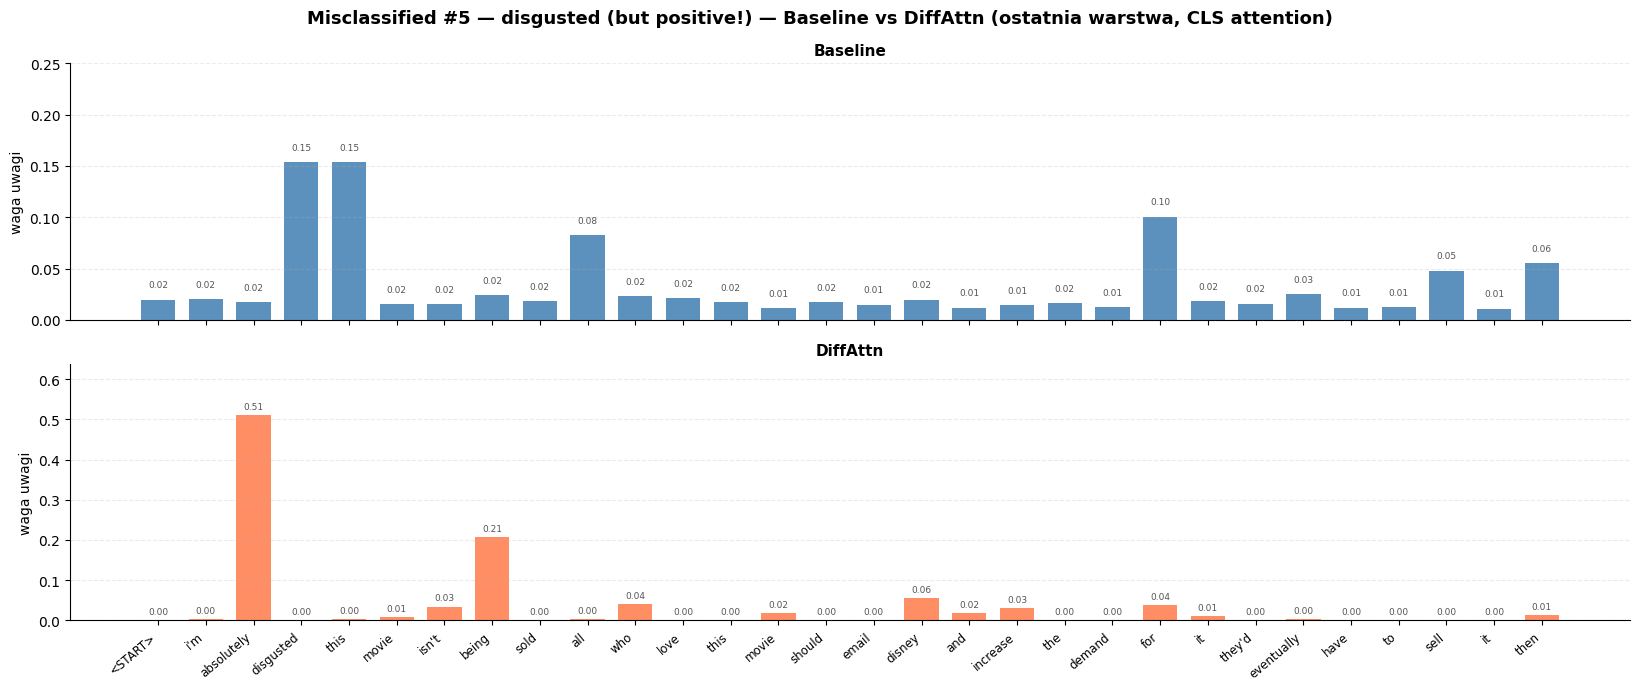

In [35]:
# === PORÓWNANIE: NA CZYM SKUPIA SIĘ BASELINE VS DIFFATTN ===
# DiffAttn może zwracać wartości ujemne, więc do porównania wizualnego
# używamy wartości bezwzględnej i normalizacji do sumy 1.

from tensorflow.keras.datasets import imdb as keras_imdb


def clear_all_hooks(module):
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()
    module._backward_pre_hooks.clear()


# Usuwamy ewentualne hooki pozostawione przez wcześniejsze komórki analizy.
clear_all_hooks(baseline.transformer.layers[-1].self_attn)
clear_all_hooks(diff_model.layers[-1].attn)

word_index = keras_imdb.get_word_index()
idx_to_word = {v + 3: k for k, v in word_index.items()}
idx_to_word[0] = '<PAD>'
idx_to_word[1] = '<START>'
idx_to_word[2] = '<OOV>'


def decode_tokens(sequence, max_words=30):
    return [idx_to_word.get(int(token), '?') for token in sequence[:max_words]]


def predict_label(model, sequence, device=DEVICE):
    model.eval()
    tokens = torch.tensor([[VOCAB_SIZE] + list(sequence[:MAX_LEN])], dtype=torch.long, device=device)
    with torch.no_grad():
        logits = model(tokens)
    probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    pred = int(probs.argmax())
    return pred, probs


def baseline_cls_attention(model, sequence, device=DEVICE, max_words=30):
    model.eval()
    tokens_only = list(sequence[:max_words])
    tokens = torch.tensor([[VOCAB_SIZE] + tokens_only], dtype=torch.long, device=device)
    seq_len = tokens.size(1)

    with torch.no_grad():
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        hidden = model.dropout(model.token_emb(tokens) + model.pos_emb(positions))

        for layer in model.transformer.layers[:-1]:
            hidden = layer(hidden)

        last_layer = model.transformer.layers[-1]
        query = last_layer.norm1(hidden) if getattr(last_layer, 'norm_first', False) else hidden
        _, attn = last_layer.self_attn(
            query,
            query,
            query,
            need_weights=True,
            average_attn_weights=False,
        )

    attn = attn.mean(dim=1)[0].detach().cpu().numpy()  # (T, T)
    scores = np.maximum(attn[0, 1:seq_len], 0.0)
    scores = scores / (scores.sum() + 1e-9)
    return decode_tokens(sequence, max_words), scores


def diff_cls_attention(model, sequence, device=DEVICE, max_words=30):
    model.eval()
    tokens_only = list(sequence[:max_words])
    tokens = torch.tensor([[VOCAB_SIZE] + tokens_only], dtype=torch.long, device=device)

    with torch.no_grad():
        model(tokens, store_attn=True)
        attn = model.get_attention_weights()  # (B, H, T, T)

    attn = attn.abs().mean(dim=1)[0].detach().cpu().numpy()  # (T, T)
    seq_len = len(tokens_only) + 1
    scores = attn[0, 1:seq_len]
    scores = scores / (scores.sum() + 1e-9)
    return decode_tokens(sequence, max_words), scores


def plot_attention_comparison(tokens, base_scores, diff_scores, title):
    n = len(tokens)
    x = np.arange(n)
    fig, axes = plt.subplots(2, 1, figsize=(max(14, n * 0.55), 7), sharex=True)

    plots = [
        (axes[0], base_scores, 'steelblue', 'Baseline'),
        (axes[1], diff_scores, 'coral', 'DiffAttn'),
    ]

    for ax, scores, color, label in plots:
        bars = ax.bar(x, scores, color=color, alpha=0.88, width=0.72)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_ylabel('waga uwagi')
        ax.set_ylim(0, max(0.25, float(scores.max()) * 1.25))
        ax.grid(axis='y', alpha=0.25, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        for bar, val in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5, color='#555555')

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tokens, rotation=40, ha='right', fontsize=8.5)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_focus(sequence, label, max_words=30, device=DEVICE):
    tokens, base_scores = baseline_cls_attention(baseline, sequence, device=device, max_words=max_words)
    _, diff_scores = diff_cls_attention(diff_model, sequence, device=device, max_words=max_words)

    base_pred, base_probs = predict_label(baseline, sequence, device=device)
    diff_pred, diff_probs = predict_label(diff_model, sequence, device=device)
    review_text = ' '.join(tokens)

    print('=' * 90)
    print(label)
    print('=' * 90)
    print('Tekst opinii:')
    print(review_text)
    print()
    print(f'Baseline pred: {base_pred} | probs: [{base_probs[0]:.3f}, {base_probs[1]:.3f}]')
    print(f'DiffAttn pred: {diff_pred} | probs: [{diff_probs[0]:.3f}, {diff_probs[1]:.3f}]')
    print(f'Top tokens baseline: {sorted(zip(tokens, base_scores), key=lambda x: x[1], reverse=True)[:5]}')
    print(f'Top tokens diffattn: {sorted(zip(tokens, diff_scores), key=lambda x: x[1], reverse=True)[:5]}')

    plot_attention_comparison(
        tokens,
        base_scores,
        diff_scores,
        title=f'{label} — Baseline vs DiffAttn (ostatnia warstwa, CLS attention)'
    )


compare_focus(x_test[36], 'Positive #36 — greatest films ever made', max_words=30)
compare_focus(x_test[39], 'Negative #39 — boring and quite stupid', max_words=30)
compare_focus(x_test[5], 'Misclassified #5 — disgusted (but positive!)', max_words=30)